# SVM for Conspiracy Detection
## Binary classification (yes/no only)

This notebook implements Support Vector Machine (SVM) classifier for:
1. **Conspiracy Label Prediction**: **binary (yes/no only)** — "cant_tell" samples are excluded (same as train_and_infer_binary.py)
2. **Model Evaluation**: 5-fold cross-validation on training set
3. **Validation Set Testing**: Evaluation on 100 samples held out from the training pool (same feature pipeline)
4. **Final Test Set**: Evaluation on dev set (dev_public.jsonl labels + features from **features_dev/**). Run `python3 code/extract_dev_features.py` first to extract the 62 features for dev_rehydrated.jsonl.


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [11]:
# Load and merge all features
BASE = Path('../')
PROC = BASE / 'data_processed'
FEAT = BASE / 'features'

# Load base data from data_clean.csv (contains _id, text, conspiracy)
df = pd.read_csv(PROC / 'data_clean.csv')

# Binary classification only: ignore "cant_tell" (same as train_and_infer_binary.py)
n_before = len(df)
df = df[df['conspiracy'].isin(['yes', 'no'])].copy()
n_after = len(df)
print(f"Binary classification: kept only yes/no, excluded {n_before - n_after} 'cant_tell' samples")
print(f"Base data: {df.shape}")
print(f"Base columns: {list(df.columns)}")
print(f"Base data row count: {len(df)}")

# Preserve original columns from data_clean.csv
base_cols = ['_id', 'text', 'conspiracy']
for col in base_cols:
    if col not in df.columns:
        print(f"WARNING: {col} not found in base data!")

# Store base _id values to ensure we only keep these rows
base_ids = set(df['_id'].values)
print(f"Unique _id values in base: {len(base_ids)}")

# Load feature files
feature_files = [
    FEAT / 'lexical_complexity.csv',
    FEAT / 'discourse_markers.csv',
    FEAT / 'sentiment_emotion.csv',
    FEAT / 'token_pos_counts.csv',
    FEAT / 'readability_scores.csv',
    FEAT / 'ma_ttr_mtld_scores.csv',
    FEAT / 'pos_analysis.csv'
]

# Start with base data - this preserves _id, text, conspiracy from data_clean.csv
merged = df.copy()
initial_row_count = len(merged)

# Merge feature files, ensuring we keep original columns from data_clean.csv
# and preserve the exact row count from base data
for feat_file in feature_files:
    if feat_file.exists():
        try:
            feat_df = pd.read_csv(feat_file)
            print(f"\nLoading {feat_file.name}: {feat_df.shape[0]} rows, {feat_df.shape[1]} columns")
            
            if '_id' in merged.columns and '_id' in feat_df.columns:
                # Filter feature file to only include rows with _id in base data
                feat_df_filtered = feat_df[feat_df['_id'].isin(base_ids)].copy()
                print(f"  Filtered to {len(feat_df_filtered)} rows matching base _id values")
                
                # Remove duplicates by _id (keep first occurrence) to prevent row explosion
                initial_filtered_count = len(feat_df_filtered)
                feat_df_filtered = feat_df_filtered.drop_duplicates(subset=['_id'], keep='first')
                if len(feat_df_filtered) < initial_filtered_count:
                    print(f"  Removed {initial_filtered_count - len(feat_df_filtered)} duplicate _id rows (kept first)")
                
                # Drop any columns from feature file that conflict with base_cols (except _id)
                cols_to_drop = [col for col in feat_df_filtered.columns if col in base_cols and col != '_id']
                if cols_to_drop:
                    feat_df_filtered = feat_df_filtered.drop(columns=cols_to_drop)
                    print(f"  Dropped conflicting columns: {cols_to_drop}")
                
                # Merge on _id, keeping all rows from merged (left join)
                merged = merged.merge(feat_df_filtered, on='_id', how='left')
                print(f"  Merged successfully. Merged shape: {merged.shape}")
            else:
                print(f"  Skipped: missing '_id' column")
        except Exception as e:
            print(f"Could not load {feat_file.name}: {e}")

# Verify that original columns from data_clean.csv are still present
for col in base_cols:
    if col not in merged.columns:
        print(f"ERROR: {col} was lost during merge!")

# Verify row count is preserved
if len(merged) != initial_row_count:
    print(f"\nWARNING: Row count changed from {initial_row_count} to {len(merged)}!")
else:
    print(f"\n✓ Row count preserved: {initial_row_count}")

print(f"\nFinal merged shape: {merged.shape}")
print(f"Total columns: {len(merged.columns)}")
print(f"Original columns preserved: {all(col in merged.columns for col in base_cols)}")
print(f"\nColumn breakdown:")
print(f"  Base columns: {base_cols}")
print(f"  Feature columns added: {len(merged.columns) - len(base_cols)}")
print(f"\nFirst few rows (showing base columns + first 5 feature columns):")
feature_cols = [col for col in merged.columns if col not in base_cols][:5]
print(merged[base_cols + feature_cols].head())


Binary classification: kept only yes/no, excluded 0 'cant_tell' samples
Base data: (3011, 3)
Base columns: ['_id', 'text', 'conspiracy']
Base data row count: 3011
Unique _id values in base: 3011

Loading lexical_complexity.csv: 3011 rows, 5 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 7)

Loading discourse_markers.csv: 3011 rows, 5 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 11)

Loading sentiment_emotion.csv: 3011 rows, 5 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 15)

Loading token_pos_counts.csv: 3011 rows, 8 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 22)

Loading ma_ttr_mtld_scores.csv: 3011 rows, 3 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 24)

Loading pos_analysis.csv: 3011 rows, 36 columns
  Filt

In [12]:
# Create validation set (100 randomly selected points)
# This validation set will be saved and reused across all ML notebooks
from sklearn.model_selection import train_test_split

VALIDATION_SIZE = 100
VALIDATION_FILE = PROC / 'validation_set_ids.csv'

# Set random seed for reproducibility
np.random.seed(42)

# Check if validation set already exists
if VALIDATION_FILE.exists():
    print("Loading existing validation set...")
    validation_ids_df = pd.read_csv(VALIDATION_FILE)
    validation_ids = set(validation_ids_df['_id'].values)
    print(f"  Loaded {len(validation_ids)} validation IDs from {VALIDATION_FILE.name}")
else:
    print(f"Creating new validation set ({VALIDATION_SIZE} samples)...")
    
    # Use stratified sampling to maintain class distribution
    label_counts = merged['conspiracy'].value_counts()
    print(f"  Class distribution: {dict(label_counts)}")
    
    target_fraction = VALIDATION_SIZE / len(merged)
    
    # Perform stratified split
    train_ids, val_ids = train_test_split(
        merged['_id'].values,
        test_size=target_fraction,
        stratify=merged['conspiracy'].values,
        random_state=42
    )
    
    # Adjust to exactly 100 if needed
    if len(val_ids) > VALIDATION_SIZE:
        val_df_temp = merged[merged['_id'].isin(val_ids)]
        val_ids_adjusted, _ = train_test_split(
            val_ids,
            test_size=VALIDATION_SIZE / len(val_ids),
            stratify=val_df_temp['conspiracy'].values,
            random_state=42
        )
        validation_ids = set(val_ids_adjusted)
    elif len(val_ids) < VALIDATION_SIZE:
        train_df_temp = merged[merged['_id'].isin(train_ids)]
        additional_needed = VALIDATION_SIZE - len(val_ids)
        additional_ids, _ = train_test_split(
            train_ids,
            test_size=additional_needed / len(train_ids),
            stratify=train_df_temp['conspiracy'].values,
            random_state=42
        )
        validation_ids = set(list(val_ids) + list(additional_ids))
    else:
        validation_ids = set(val_ids)
    
    # Save validation set IDs
    validation_ids_df = pd.DataFrame({'_id': list(validation_ids)})
    validation_ids_df.to_csv(VALIDATION_FILE, index=False)
    print(f"  ✓ Saved validation set to {VALIDATION_FILE.name}")
    print(f"  Validation set size: {len(validation_ids)} samples")

# Display validation set distribution
validation_df = merged[merged['_id'].isin(validation_ids)]
print(f"\nValidation set class distribution:")
print(validation_df['conspiracy'].value_counts().to_dict())

# Remove validation set from training data
train_df = merged[~merged['_id'].isin(validation_ids)].copy()
print(f"\nTraining set size: {len(train_df)} samples")
print(f"Training set class distribution:")
print(train_df['conspiracy'].value_counts().to_dict())

# Update merged to be training data only
merged = train_df.copy()
print(f"\n✓ Updated merged dataframe for training: {merged.shape}")

# Keep validation set with features for later evaluation (100 held-out from training pool)
validation_merged = validation_df.copy()
print(f"✓ Validation set with features kept: {validation_merged.shape} (for 'Testing on Validation Set' block)")


Loading existing validation set...
  Loaded 100 validation IDs from validation_set_ids.csv

Validation set class distribution:
{'no': 57, 'yes': 43}

Training set size: 2911 samples
Training set class distribution:
{'no': 1651, 'yes': 1260}

✓ Updated merged dataframe for training: (2911, 59)
✓ Validation set with features kept: (100, 59) (for 'Testing on Validation Set' block)


In [13]:
# Extract numeric features
numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
# Remove _id and other non-feature columns
numeric_cols = [c for c in numeric_cols if c not in ['_id']]
print(f"Number of numeric features: {len(numeric_cols)}")

X = merged[numeric_cols].fillna(0)
print(X.head())
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values: {X.isna().sum().sum()}")


Number of numeric features: 56
        ttr  hapax_ratio  avg_word_len  shannon_entropy  hedge_count  \
0  0.857143     0.714286      4.678571         4.521641            0   
1  0.761905     0.587302      4.920635         5.431811            0   
2  0.818182     0.675325      4.259740         5.867372            0   
3  0.666667     0.555556      4.685185         4.752314            0   
4  0.797101     0.666667      3.797101         5.648025            0   

   certainty_count  discourse_count  passive_count    neg    neu  ...  \
0                0                0              0  0.000  0.799  ...   
1                0                0              1  0.034  0.908  ...   
2                0                0              1  0.073  0.868  ...   
3                0                0              3  0.113  0.851  ...   
4                0                0              0  0.165  0.771  ...   

   adp_ratio  cconj_ratio  sconj_ratio  num_ratio  part_ratio  intj_ratio  \
0   0.166667     0.0

## Task 1: Conspiracy Label Prediction (binary: yes/no only)


In [14]:
# Task 1: Conspiracy Label Prediction (binary: yes/no only)
y_conspiracy = merged['conspiracy'].copy()
# Filter out any null labels (data is already restricted to yes/no in cell 2)
mask = y_conspiracy.notna()
X_clean = X[mask]
y_clean = y_conspiracy[mask]

print(f"Samples for conspiracy prediction (binary): {len(y_clean)}")
print(f"Label distribution (yes/no only):")
print(y_clean.value_counts())

# Encode labels
le_conspiracy = LabelEncoder()
y_encoded = le_conspiracy.fit_transform(y_clean)
print(f"Encoded labels: {dict(zip(le_conspiracy.classes_, range(len(le_conspiracy.classes_))))}")

# Create pipeline with scaling and SVM
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

# 4-fold cross-validation
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']
cv_results = cross_validate(pipeline, X_clean, y_encoded, cv=cv, scoring=scoring, n_jobs=-1)

print("\n=== Conspiracy Label Prediction - Binary yes/no (4-fold CV) ===")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Train final model
pipeline.fit(X_clean, y_encoded)
print("\nModel trained successfully!")


Samples for conspiracy prediction (binary): 2911
Label distribution (yes/no only):
conspiracy
no     1651
yes    1260
Name: count, dtype: int64
Encoded labels: {'no': 0, 'yes': 1}



=== Conspiracy Label Prediction - Binary yes/no (4-fold CV) ===
accuracy: 0.5847 (+/- 0.0219)
f1_macro: 0.5380 (+/- 0.0243)
f1_weighted: 0.5576 (+/- 0.0225)
precision_macro: 0.5687 (+/- 0.0303)
recall_macro: 0.5521 (+/- 0.0209)

Model trained successfully!


## Testing on Validation Set (100 held-out from training pool)

Evaluate the trained model on the **internal** validation set: 100 samples held out from the training pool (same feature pipeline as training).


In [15]:
# --- 1) Validation set (100 held-out from training pool): build X_val, y_val for next cell ---
validation_binary = validation_merged[validation_merged['conspiracy'].isin(['yes', 'no'])].copy()
X_val = validation_binary[numeric_cols].fillna(0)
y_val = validation_binary['conspiracy'].copy()
y_val_encoded = le_conspiracy.transform(y_val)

print("=== Validation Set (100 held-out from training pool) ===")
print(f"Validation samples (binary yes/no): {len(validation_binary)}")
print(f"Feature matrix: {X_val.shape}")
print(f"Class distribution: {y_val.value_counts().to_dict()}")

# --- 2) Final test set: dev_public labels + features from features_dev/ (run code/extract_dev_features.py first) ---
DEV_PUBLIC_PATH = BASE / 'data' / 'dev_public.jsonl'
FEAT_DEV = BASE / 'features_dev'

feature_files_dev = [
    FEAT_DEV / 'lexical_complexity.csv',
    FEAT_DEV / 'discourse_markers.csv',
    FEAT_DEV / 'sentiment_emotion.csv',
    FEAT_DEV / 'token_pos_counts.csv',
    FEAT_DEV / 'readability_scores.csv',
    FEAT_DEV / 'ma_ttr_mtld_scores.csv',
    FEAT_DEV / 'pos_analysis.csv',
]

def load_dev_jsonl(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            row = json.loads(line.strip())
            rows.append({'_id': row['_id'], 'conspiracy': row.get('conspiracy')})
    return pd.DataFrame(rows)

def normalize_conspiracy(s):
    if pd.isna(s) or s is None:
        return s
    s = str(s).strip().lower()
    if "can't tell" in s or s == "cant_tell":
        return 'cant_tell'
    if s == 'yes' or s == 'no':
        return s
    if s in ('y', 'true', '1'):
        return 'yes'
    if s in ('n', 'false', '0'):
        return 'no'
    return 'cant_tell'

dev_public_df = load_dev_jsonl(DEV_PUBLIC_PATH)
dev_public_df['conspiracy'] = dev_public_df['conspiracy'].map(normalize_conspiracy)
dev_public_df = dev_public_df[dev_public_df['conspiracy'].isin(['yes', 'no'])].copy()
dev_ids = set(dev_public_df['_id'].values)

dev_merged = dev_public_df.copy()
for feat_file in feature_files_dev:
    if feat_file.exists():
        feat_df = pd.read_csv(feat_file)
        if '_id' in feat_df.columns:
            feat_df = feat_df[feat_df['_id'].isin(dev_ids)].drop_duplicates(subset=['_id'], keep='first')
            cols_to_drop = [c for c in feat_df.columns if c in base_cols and c != '_id']
            if cols_to_drop:
                feat_df = feat_df.drop(columns=cols_to_drop)
            dev_merged = dev_merged.merge(feat_df, on='_id', how='left')
    else:
        print(f"Warning: {feat_file.name} not found. Run: python3 code/extract_dev_features.py")

for col in numeric_cols:
    if col not in dev_merged.columns:
        dev_merged[col] = 0
X_dev = dev_merged[numeric_cols].fillna(0) if dev_merged.shape[0] > 0 else None
y_dev = dev_merged['conspiracy'].copy()

print("\n=== Final Test Set (dev_public.jsonl + features_dev/) ===")
if X_dev is not None:
    print(f"Dev samples (binary yes/no): {len(dev_merged)}")
    print(f"Dev feature matrix: {X_dev.shape}")
    print(f"Class distribution: {y_dev.value_counts().to_dict()}")
else:
    print("Dev features not available. Run: python3 code/extract_dev_features.py")


=== Validation Set (100 held-out from training pool) ===
Validation samples (binary yes/no): 100
Feature matrix: (100, 56)
Class distribution: {'no': 57, 'yes': 43}

=== Final Test Set (dev_public.jsonl + features_dev/) ===
Dev samples (binary yes/no): 77
Dev feature matrix: (77, 56)
Class distribution: {'no': 50, 'yes': 27}


=== Validation Set Predictions ===

True label distribution:
{'no': 57, 'yes': 43}

Predicted label distribution:
{'no': np.int64(77), 'yes': np.int64(23)}

=== Validation Set Performance ===
Accuracy: 0.5400
F1 (macro): 0.4799
F1 (weighted): 0.5046

=== Detailed Classification Report ===
              precision    recall  f1-score   support

          no       0.57      0.77      0.66        57
         yes       0.43      0.23      0.30        43

    accuracy                           0.54       100
   macro avg       0.50      0.50      0.48       100
weighted avg       0.51      0.54      0.50       100


=== Confusion Matrix ===
Rows = True labels, Columns = Predicted labels
Label order: ['no', 'yes']
[[44 13]
 [33 10]]


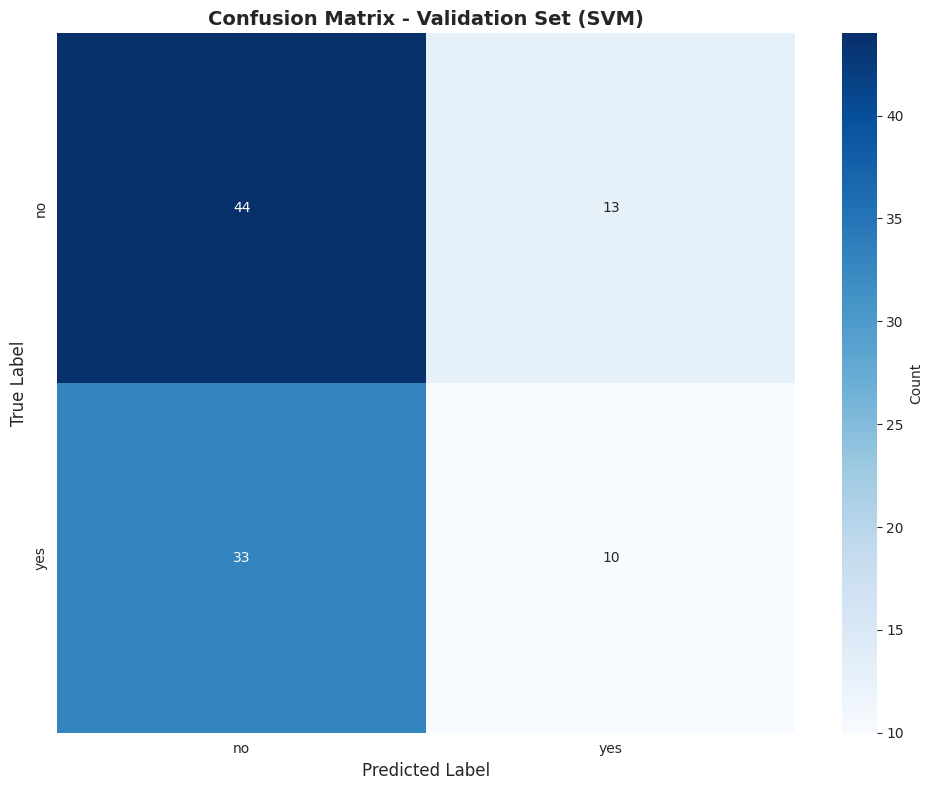


✓ Saved confusion matrix to figures/validation_confusion_matrix_svm.png


In [16]:
# Make predictions on validation set
y_val_pred = pipeline.predict(X_val)
y_val_pred_labels = le_conspiracy.inverse_transform(y_val_pred)

print("=== Validation Set Predictions ===")
print(f"\nTrue label distribution:")
print(y_val.value_counts().to_dict())

print(f"\nPredicted label distribution:")
unique, counts = np.unique(y_val_pred_labels, return_counts=True)
print(dict(zip(unique, counts)))

# Calculate metrics
val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
val_f1_macro = f1_score(y_val_encoded, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val_encoded, y_val_pred, average='weighted')

print(f"\n=== Validation Set Performance ===")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"F1 (macro): {val_f1_macro:.4f}")
print(f"F1 (weighted): {val_f1_weighted:.4f}")

# Detailed classification report
print(f"\n=== Detailed Classification Report ===")
print(classification_report(y_val, y_val_pred_labels, target_names=le_conspiracy.classes_))

# Confusion matrix
cm = confusion_matrix(y_val_encoded, y_val_pred)
print(f"\n=== Confusion Matrix ===")
print("Rows = True labels, Columns = Predicted labels")
print(f"Label order: {list(le_conspiracy.classes_)}")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_conspiracy.classes_, 
            yticklabels=le_conspiracy.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Validation Set (SVM)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(BASE / 'figures' / 'validation_confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved confusion matrix to figures/validation_confusion_matrix_svm.png")


In [17]:
# Compare predictions with true labels for some examples
print("\n=== Sample Predictions (validation set) ===")
n_val = len(y_val)
sample_indices = np.random.choice(n_val, size=min(10, n_val), replace=False)

results_df = pd.DataFrame({
    '_id': validation_binary.iloc[sample_indices]['_id'].values,
    'true_label': y_val.iloc[sample_indices].values,
    'predicted_label': y_val_pred_labels[sample_indices],
    'correct': (y_val.iloc[sample_indices].values == y_val_pred_labels[sample_indices])
})

print(results_df.to_string(index=False))

print(f"\n✓ Validation set evaluation complete!")
print(f"  Total validation samples (binary): {n_val}")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"  Correct predictions: {(y_val.values == y_val_pred_labels).sum()}/{len(y_val)}")



=== Sample Predictions (validation set) ===
       _id true_label predicted_label  correct
t1_gxdbb93         no             yes    False
t1_f46r0ke        yes             yes     True
t1_g3kjdpy        yes             yes     True
t1_gncesez         no              no     True
t1_jjkrax5         no             yes    False
t1_fwa4gqt        yes              no    False
t1_gk0n303        yes              no    False
t1_es8hyiq        yes              no    False
t1_ix3m10u         no              no     True
t1_e93zmh3         no              no     True

✓ Validation set evaluation complete!
  Total validation samples (binary): 100
  Accuracy: 0.5400
  Correct predictions: 54/100


## Final evaluation on dev set (100 samples, features from features_dev/)

Evaluate the trained model on the **final test set**: 100 samples from `dev_public.jsonl` with labels, using 62 features extracted for `dev_rehydrated.jsonl` via `python3 code/extract_dev_features.py`.

=== Final Test Set (dev) Predictions ===

True label distribution:
{'no': 50, 'yes': 27}

Predicted label distribution:
{'no': 61, 'yes': 16}

=== Final Test Set (dev) Performance ===
Accuracy: 0.6494
F1 (macro): 0.5644
F1 (weighted): 0.6219

=== Classification Report (dev) ===
              precision    recall  f1-score   support

          no       0.69      0.84      0.76        50
         yes       0.50      0.30      0.37        27

    accuracy                           0.65        77
   macro avg       0.59      0.57      0.56        77
weighted avg       0.62      0.65      0.62        77

=== Confusion Matrix (dev) ===
Rows = True, Columns = Predicted
[[42  8]
 [19  8]]


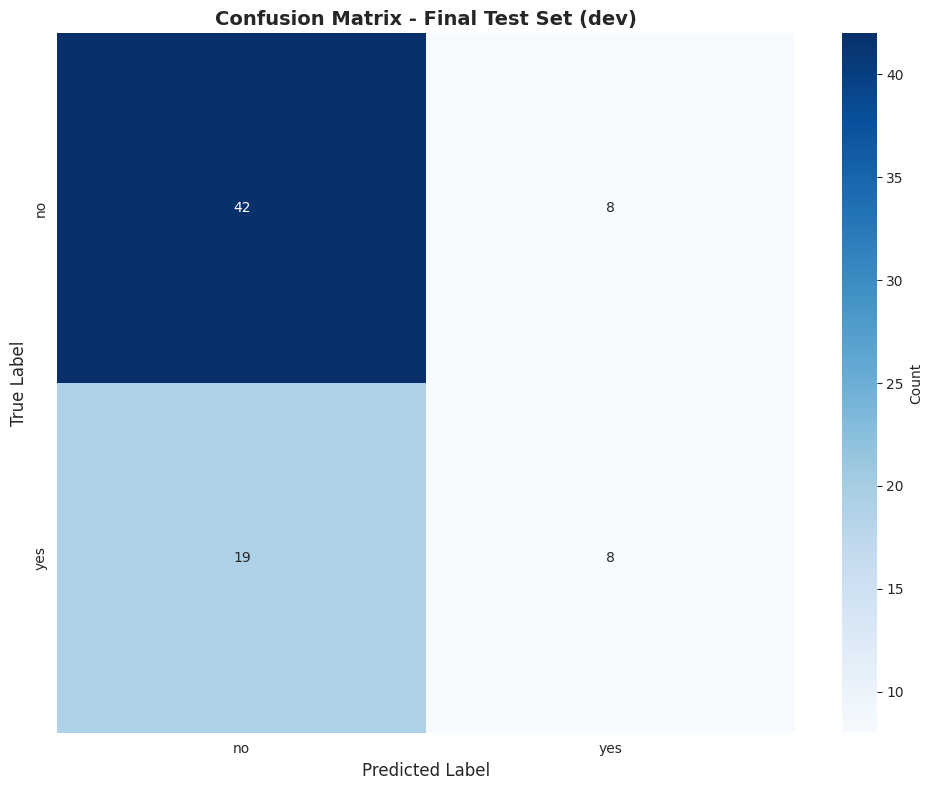


✓ Saved confusion matrix to figures/dev_confusion_matrix_svm.png

✓ Final test set evaluation complete: 77 samples (dev_public with features_dev)


In [18]:
# Final test set evaluation (dev_public + features_dev)
if X_dev is not None and len(X_dev) > 0:
    y_dev_pred = pipeline.predict(X_dev)
    y_dev_pred_labels = le_conspiracy.inverse_transform(y_dev_pred)
    y_dev_encoded = le_conspiracy.transform(y_dev)

    print("=== Final Test Set (dev) Predictions ===")
    print(f"\nTrue label distribution:\n{y_dev.value_counts().to_dict()}")
    print(f"\nPredicted label distribution:\n{pd.Series(y_dev_pred_labels).value_counts().to_dict()}")

    dev_accuracy = accuracy_score(y_dev_encoded, y_dev_pred)
    dev_f1_macro = f1_score(y_dev_encoded, y_dev_pred, average='macro')
    dev_f1_weighted = f1_score(y_dev_encoded, y_dev_pred, average='weighted')

    print(f"\n=== Final Test Set (dev) Performance ===")
    print(f"Accuracy: {dev_accuracy:.4f}")
    print(f"F1 (macro): {dev_f1_macro:.4f}")
    print(f"F1 (weighted): {dev_f1_weighted:.4f}")
    print(f"\n=== Classification Report (dev) ===")
    print(classification_report(y_dev, y_dev_pred_labels, target_names=le_conspiracy.classes_))
    print("=== Confusion Matrix (dev) ===")
    print("Rows = True, Columns = Predicted")
    cm_dev = confusion_matrix(y_dev_encoded, y_dev_pred)
    print(cm_dev)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_dev, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_conspiracy.classes_,
                yticklabels=le_conspiracy.classes_,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Final Test Set (dev)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / 'dev_confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Saved confusion matrix to figures/dev_confusion_matrix_svm.png")
    print(f"\n✓ Final test set evaluation complete: {len(y_dev)} samples (dev_public with features_dev)")
else:
    print("Skipping final test set: run 'python3 code/extract_dev_features.py' and re-run the notebook.")